# Music Mood Classifier — Part 1: Data Loading & Exploratory Data Analysis

This notebook loads the raw Spotify track dataset and performs a thorough exploratory data analysis (EDA). We examine the data structure, feature distributions, missing values, and the original genre taxonomy before collapsing 114 genre labels into 6 acoustically distinct super-genres.

**Notebooks in this series:**
1. Data Loading & Exploratory Data Analysis *(this notebook)*
2. Preprocessing & Feature Engineering
3. Model Selection, Tuning & Training
4. Model Evaluation


## 1. Setup

Import all required libraries and configure global plot settings.


In [19]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded.')


Libraries loaded.


## 2. Configuration

All project settings are defined here as Python variables. No command-line arguments are used; modify this cell to change any setting.


In [20]:
# ==== Project Configuration ====
DATA_PATH       = Path('dataset.csv')
RANDOM_SEED     = 42
TARGET_COLUMN   = 'track_genre'
INDEX_COLUMN    = 'Unnamed: 0'

DROP_COLUMNS = ['track_id', 'artists', 'album_name', 'track_name']

NUMERIC_FEATURES = [
    'popularity', 'duration_ms', 'explicit',
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature',
]

print('Configuration ready.')
print(f'Data path : {DATA_PATH}')
print(f'Target    : {TARGET_COLUMN}')
print(f'Features  : {len(NUMERIC_FEATURES)} numeric features')


Configuration ready.
Data path : dataset.csv
Target    : track_genre
Features  : 15 numeric features


## 3. Genre Taxonomy

The raw dataset contains **114 Spotify genre labels**. Many are acoustically near-identical sub-genres (e.g. `metal` and `heavy-metal`, `indie` and `indie-pop`) that a feature-based classifier cannot separate. Through four rounds of per-class accuracy analysis, all 114 labels are collapsed into **6 acoustically distinct super-genres**, each defined by strong, measurable audio axes.

| Super-Genre | Key Audio Signal | Sub-genre Examples |
|---|---|---|
| **acoustic** | Very high acousticness, low energy | folk, classical, ambient, jazz, blues |
| **alternative** | Moderate energy, low acousticness, low danceability | indie, grunge, rock, alt-rock |
| **dance** | Very high danceability, moderate-high valence | pop, latin, R&B, K-pop, reggae |
| **electronic** | Very high energy, very low acousticness | EDM, house, techno, trance |
| **heavy** | Maximum energy and loudness, low valence | metal, punk, hardcore, emo |
| **vocal** | Very high speechiness | hip-hop, rap, children, comedy |


In [21]:
GENRE_MAPPING = {
    # --- acoustic ---
    'acoustic': 'acoustic', 'folk': 'acoustic', 'singer-songwriter': 'acoustic',
    'songwriter': 'acoustic', 'country': 'acoustic', 'bluegrass': 'acoustic',
    'honky-tonk': 'acoustic', 'guitar': 'acoustic', 'blues': 'acoustic',
    'jazz': 'acoustic', 'groove': 'acoustic', 'ambient': 'acoustic',
    'new-age': 'acoustic', 'sleep': 'acoustic', 'study': 'acoustic',
    'chill': 'acoustic', 'piano': 'acoustic', 'classical': 'acoustic',
    'opera': 'acoustic', 'romance': 'acoustic', 'sad': 'acoustic',
    # --- alternative ---
    'alternative': 'alternative', 'alt-rock': 'alternative', 'indie': 'alternative',
    'indie-pop': 'alternative', 'grunge': 'alternative', 'british': 'alternative',
    'psych-rock': 'alternative', 'garage': 'alternative', 'rock': 'alternative',
    'hard-rock': 'alternative', 'rock-n-roll': 'alternative', 'rockabilly': 'alternative',
    # --- dance ---
    'pop': 'dance', 'dance': 'dance', 'disco': 'dance', 'party': 'dance',
    'power-pop': 'dance', 'pop-film': 'dance', 'happy': 'dance',
    'synth-pop': 'dance', 'gospel': 'dance', 'soul': 'dance', 'r-n-b': 'dance',
    'funk': 'dance', 'latin': 'dance', 'latino': 'dance', 'reggaeton': 'dance',
    'dancehall': 'dance', 'salsa': 'dance', 'samba': 'dance', 'sertanejo': 'dance',
    'forro': 'dance', 'pagode': 'dance', 'mpb': 'dance', 'brazil': 'dance',
    'tango': 'dance', 'reggae': 'dance', 'dub': 'dance', 'ska': 'dance',
    'world-music': 'dance', 'afrobeat': 'dance', 'turkish': 'dance',
    'iranian': 'dance', 'french': 'dance', 'german': 'dance', 'swedish': 'dance',
    'spanish': 'dance', 'indian': 'dance', 'j-pop': 'dance', 'j-idol': 'dance',
    'j-dance': 'dance', 'anime': 'dance', 'j-rock': 'dance', 'k-pop': 'dance',
    'cantopop': 'dance', 'mandopop': 'dance', 'malay': 'dance',
    # --- electronic ---
    'edm': 'electronic', 'electronic': 'electronic', 'electro': 'electronic',
    'club': 'electronic', 'idm': 'electronic', 'house': 'electronic',
    'deep-house': 'electronic', 'chicago-house': 'electronic',
    'detroit-techno': 'electronic', 'minimal-techno': 'electronic',
    'techno': 'electronic', 'trance': 'electronic', 'progressive-house': 'electronic',
    'drum-and-bass': 'electronic', 'dubstep': 'electronic', 'breakbeat': 'electronic',
    'hardstyle': 'electronic',
    # --- heavy ---
    'metal': 'heavy', 'heavy-metal': 'heavy', 'death-metal': 'heavy',
    'black-metal': 'heavy', 'metalcore': 'heavy', 'grindcore': 'heavy',
    'emo': 'heavy', 'goth': 'heavy', 'industrial': 'heavy', 'punk': 'heavy',
    'punk-rock': 'heavy', 'hardcore': 'heavy',
    # --- vocal ---
    'hip-hop': 'vocal', 'trip-hop': 'vocal', 'kids': 'vocal', 'children': 'vocal',
    'comedy': 'vocal', 'disney': 'vocal', 'show-tunes': 'vocal',
}

SUPER_GENRES = sorted(set(GENRE_MAPPING.values()))
print(f'Total original labels in mapping : {len(GENRE_MAPPING)}')
print(f'Super-genres ({len(SUPER_GENRES)})           : {SUPER_GENRES}')


Total original labels in mapping : 114
Super-genres (6)           : ['acoustic', 'alternative', 'dance', 'electronic', 'heavy', 'vocal']


## 4. Data Loading

The dataset is a CSV file with one row per Spotify track. We load it using `pandas.read_csv` with the integer index column dropped automatically.


In [22]:
df = pd.read_csv(DATA_PATH, index_col=0)

print(f'Shape : {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Columns:')
for col in df.columns:
    print(f'  {col:<25} {df[col].dtype}')


Shape : 114,000 rows x 20 columns

Columns:
  track_id                  object
  artists                   object
  album_name                object
  track_name                object
  popularity                int64
  duration_ms               int64
  explicit                  bool
  danceability              float64
  energy                    float64
  key                       int64
  loudness                  float64
  mode                      int64
  speechiness               float64
  acousticness              float64
  instrumentalness          float64
  liveness                  float64
  valence                   float64
  tempo                     float64
  time_signature            int64
  track_genre               object


In [23]:
df.head(3)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


## 5. Missing Value Analysis

We check for missing values across all columns. The metadata columns (`artists`, `album_name`, `track_name`) will be dropped before modelling, so any missingness in them is irrelevant. All numeric feature columns should be complete.


In [24]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(4)

missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0]

if missing_report.empty:
    print('No missing values found in the dataset.')
else:
    print('Columns with missing values:')
    print(missing_report.to_string())
    print()
    print('Note: metadata columns (artists, album_name, track_name) are dropped')
    print('before modelling, so their missing values do not affect the model.')


Columns with missing values:
            missing_count  missing_pct
artists                 1       0.0009
album_name              1       0.0009
track_name              1       0.0009

Note: metadata columns (artists, album_name, track_name) are dropped
before modelling, so their missing values do not affect the model.


## 6. Target Variable: Original Distribution

The original dataset has **114 genre labels**, each with exactly 1,000 samples — perfectly balanced at the raw level. However, many of these labels are acoustically indistinguishable sub-genres, which causes the classifier to underperform at 30-35% accuracy.


In [25]:
genre_counts = df[TARGET_COLUMN].value_counts()

print(f'Unique genres        : {genre_counts.shape[0]}')
print(f'Total samples        : {len(df):,}')
print(f'Min samples per class: {genre_counts.min():,}')
print(f'Max samples per class: {genre_counts.max():,}')
print(f'Mean samples         : {genre_counts.mean():.1f}')


Unique genres        : 114
Total samples        : 114,000
Min samples per class: 1,000
Max samples per class: 1,000
Mean samples         : 1000.0


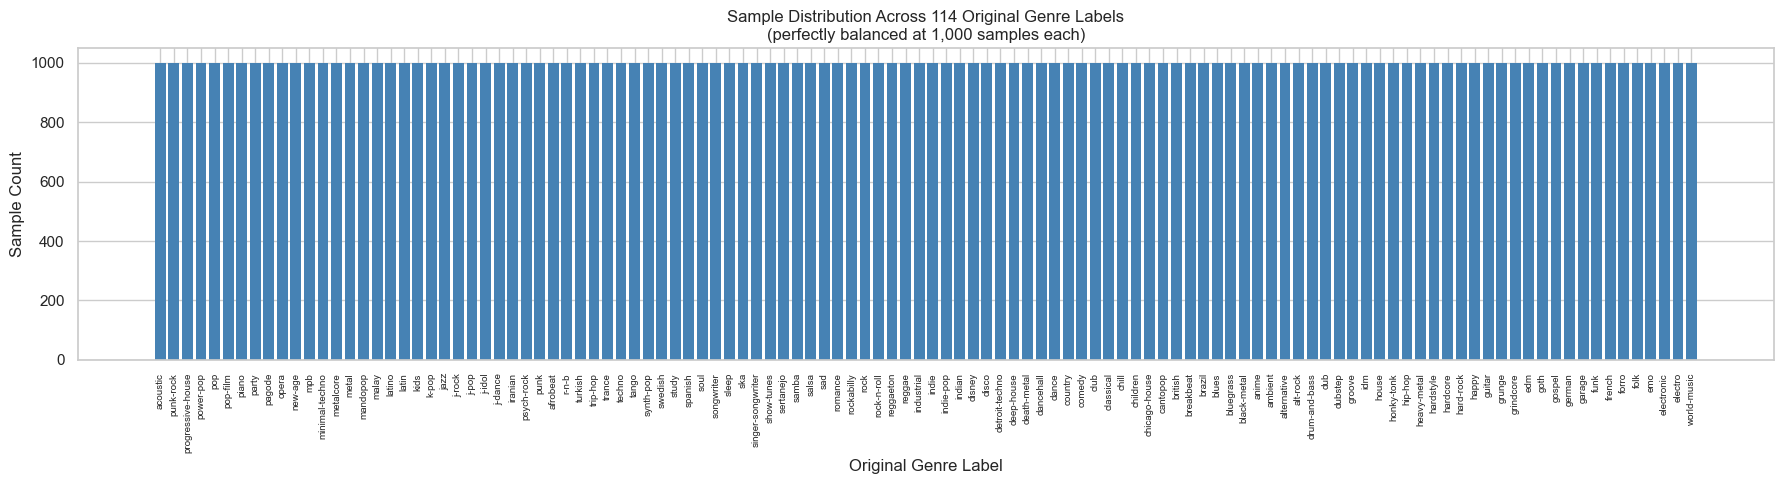

In [26]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(range(len(genre_counts)), genre_counts.values, color='steelblue', edgecolor='none')
ax.set_xticks(range(len(genre_counts)))
ax.set_xticklabels(genre_counts.index, rotation=90, fontsize=7)
ax.set_xlabel('Original Genre Label')
ax.set_ylabel('Sample Count')
ax.set_title('Sample Distribution Across 114 Original Genre Labels\n(perfectly balanced at 1,000 samples each)')
plt.tight_layout()
plt.show()


## 7. Genre Mapping: 114 Labels to 6 Super-Genres

We apply the taxonomy mapping defined in Section 3. Labels not found in the mapping are retained as-is (there should be none in this dataset).


In [27]:
df['super_genre'] = df[TARGET_COLUMN].map(lambda g: GENRE_MAPPING.get(g, g))

unmapped = set(df[TARGET_COLUMN].unique()) - set(GENRE_MAPPING.keys())
if unmapped:
    print(f'WARNING: {len(unmapped)} label(s) not in mapping (kept as-is): {sorted(unmapped)}')
else:
    print('All original genres successfully mapped to a super-genre.')

print()
super_counts = df['super_genre'].value_counts().sort_values(ascending=False)
print('Super-genre distribution:')
for genre, cnt in super_counts.items():
    pct = cnt / len(df) * 100
    print(f'  {genre:<15} {cnt:>7,}  ({pct:.1f}%)')


All original genres successfully mapped to a super-genre.

Super-genre distribution:
  dance            45,000  (39.5%)
  acoustic         21,000  (18.4%)
  electronic       17,000  (14.9%)
  alternative      12,000  (10.5%)
  heavy            12,000  (10.5%)
  vocal             7,000  (6.1%)


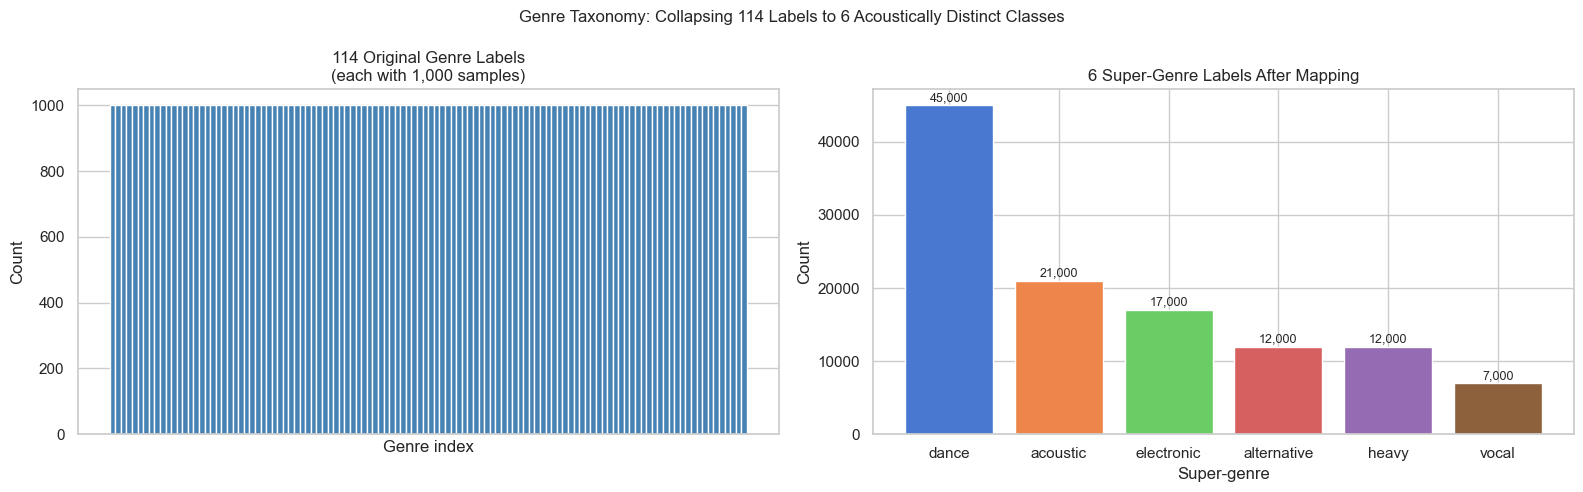

In [28]:
palette = sns.color_palette('muted', len(SUPER_GENRES))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: 114 original genres (compact bar)
axes[0].bar(range(len(genre_counts)), genre_counts.values, color='steelblue', width=1.0)
axes[0].set_title('114 Original Genre Labels\n(each with 1,000 samples)')
axes[0].set_xlabel('Genre index')
axes[0].set_ylabel('Count')
axes[0].set_xticks([])

# Right: 6 super-genres
bars = axes[1].bar(super_counts.index, super_counts.values, color=palette)
for bar, val in zip(bars, super_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{val:,}',
        ha='center', va='bottom', fontsize=9
    )
axes[1].set_title('6 Super-Genre Labels After Mapping')
axes[1].set_xlabel('Super-genre')
axes[1].set_ylabel('Count')

plt.suptitle('Genre Taxonomy: Collapsing 114 Labels to 6 Acoustically Distinct Classes', fontsize=12)
plt.tight_layout()
plt.show()


## 8. Feature Distributions

We visualise the distribution of all 15 numeric audio features. Vectorised pandas operations are used throughout — computing `.describe()`, `.quantile()`, and histogram binning all operate on contiguous NumPy arrays under the hood, making them fast even on 114,000 rows.


In [29]:
print('Descriptive statistics for all numeric features:')
df[NUMERIC_FEATURES].describe().round(3)


Descriptive statistics for all numeric features:


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000
mean,33.239,228029.153,0.567,0.641,5.309,-8.259,0.638,0.085,0.315,0.156,0.214,0.474,122.148,3.904
std,22.305,107297.713,0.174,0.252,3.560,5.029,0.481,0.106,0.333,0.310,0.190,0.259,29.978,0.433
min,0.000,0.000,0.000,0.000,0.000,-49.531,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,17.000,174066.000,0.456,0.472,2.000,-10.013,0.000,0.036,0.017,0.000,0.098,0.260,99.219,4.000
50%,35.000,212906.000,0.580,0.685,5.000,-7.004,1.000,0.049,0.169,0.000,0.132,0.464,122.017,4.000
75%,50.000,261506.000,0.695,0.854,8.000,-5.003,1.000,0.084,0.598,0.049,0.273,0.683,140.071,4.000
max,100.000,5237295.000,0.985,1.000,11.000,4.532,1.000,0.965,0.996,1.000,1.000,0.995,243.372,5.000


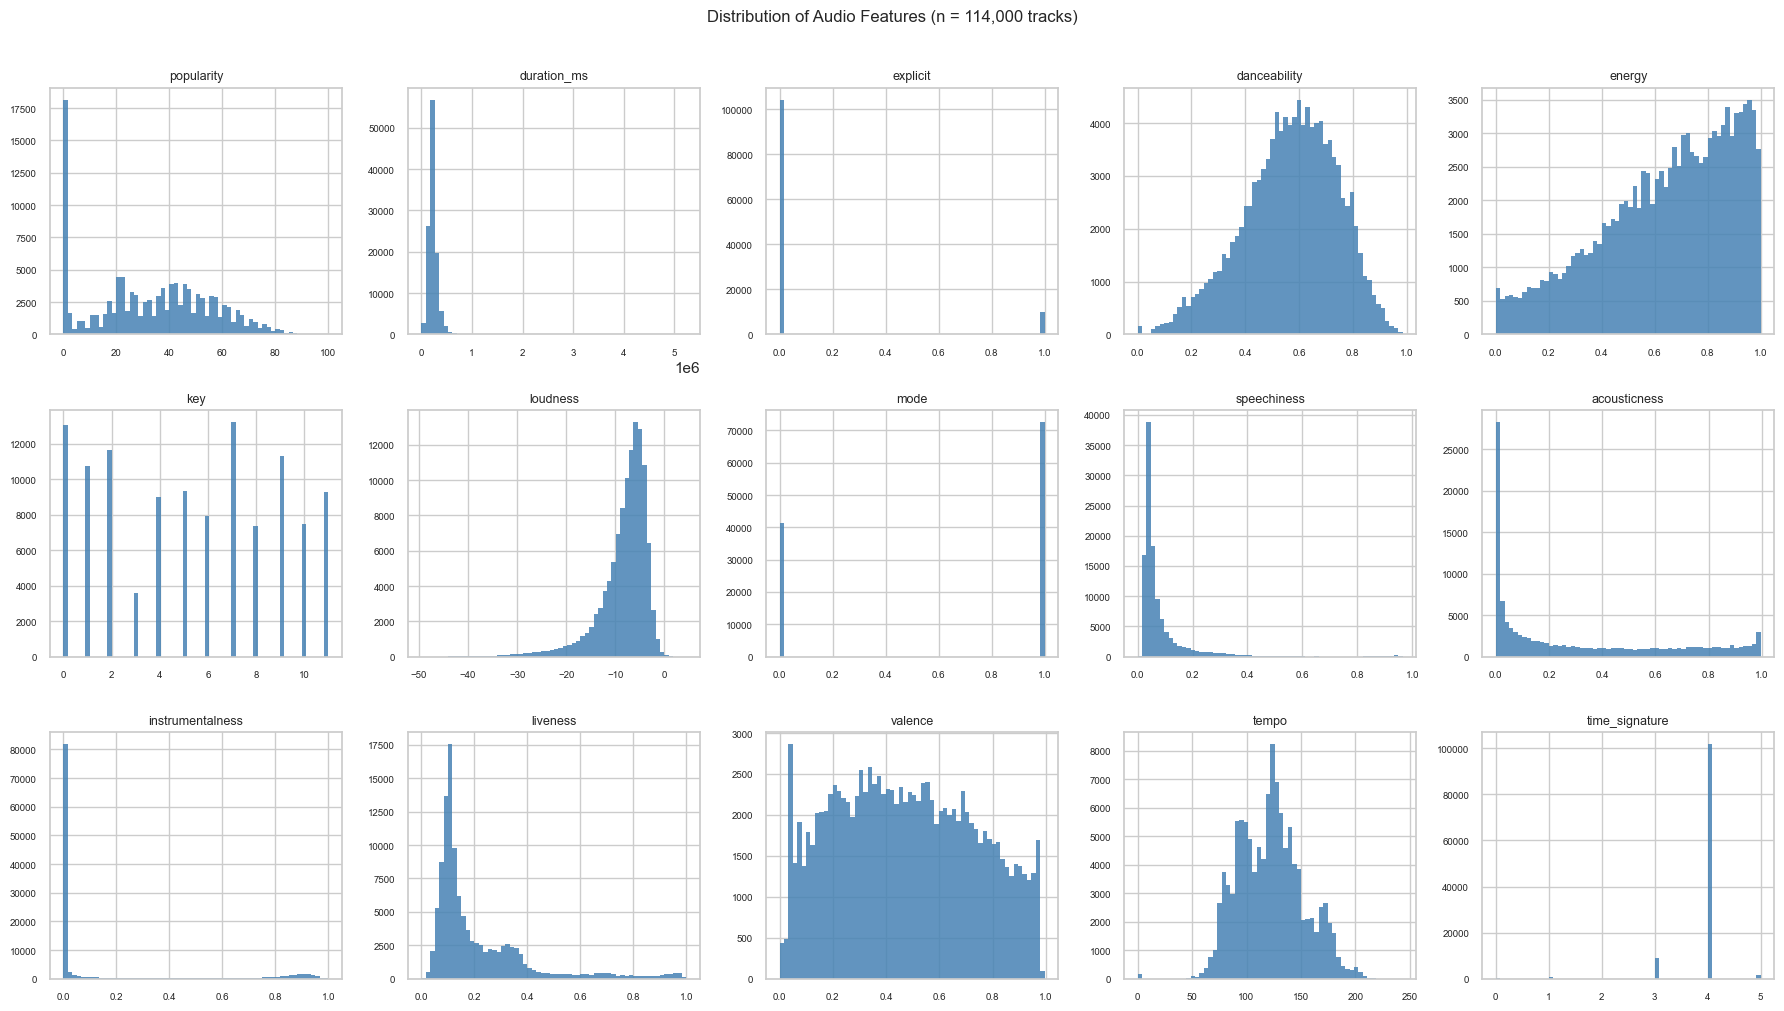

In [30]:
# Ensure only numeric features (including booleans converted to int)
numeric_features = []
for feat in NUMERIC_FEATURES:
    if pd.api.types.is_bool_dtype(df[feat]):
        df[feat] = df[feat].astype(int)  # convert boolean to 0/1
        numeric_features.append(feat)
    elif pd.api.types.is_numeric_dtype(df[feat]):
        numeric_features.append(feat)

# Grid layout
n_cols = 5
n_rows = math.ceil(len(numeric_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

# Plot histograms
for i, feat in enumerate(numeric_features):
    axes[i].hist(df[feat].dropna(), bins=60, color='steelblue', edgecolor='none', alpha=0.85)
    axes[i].set_title(feat, fontsize=9)
    axes[i].tick_params(labelsize=7)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Audio Features (n = 114,000 tracks)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### Feature Distributions by Super-Genre

Overlaying per-class distributions reveals which features are most discriminative. `acousticness`, `energy`, `danceability`, and `speechiness` show clear class separation.


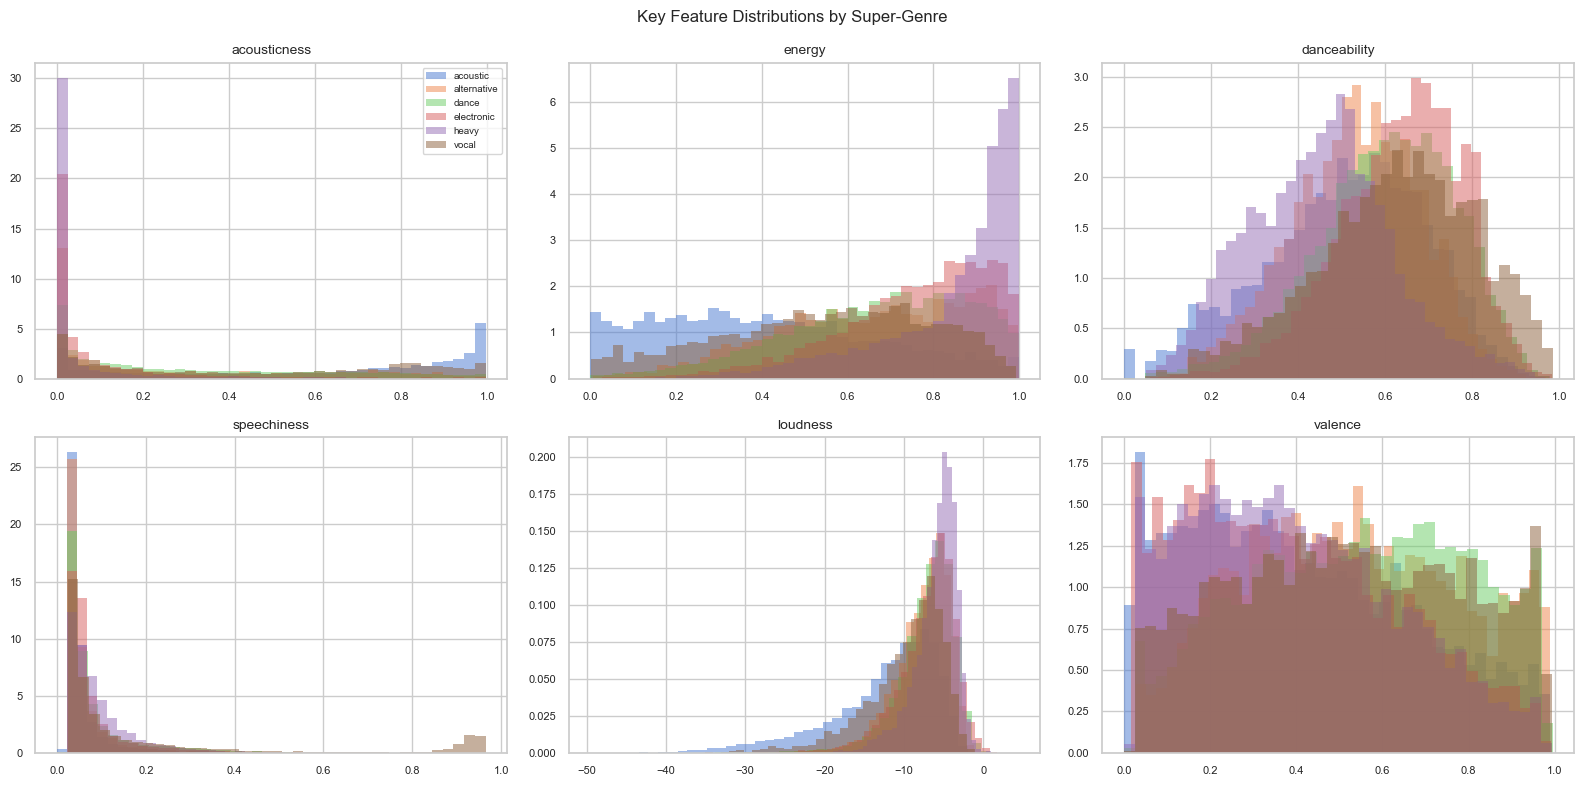

In [31]:
# Key discriminative features to highlight
key_features = ['acousticness', 'energy', 'danceability', 'speechiness',
                 'loudness', 'valence']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

palette = sns.color_palette('muted', len(SUPER_GENRES))
genre_palette = dict(zip(sorted(SUPER_GENRES), palette))

for i, feat in enumerate(key_features):
    for genre in sorted(SUPER_GENRES):
        vals = df.loc[df['super_genre'] == genre, feat].dropna()
        axes[i].hist(
            vals, bins=40, alpha=0.5, label=genre,
            color=genre_palette[genre], edgecolor='none', density=True
        )
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=8)
    if i == 0:
        axes[i].legend(fontsize=7, loc='upper right')

plt.suptitle('Key Feature Distributions by Super-Genre', fontsize=12)
plt.tight_layout()
plt.show()


## 9. Correlation Analysis

The Pearson correlation matrix reveals linear relationships between features. High energy and low acousticness are strongly negatively correlated, which is expected: electric instruments dominate energetic genres while acoustic instruments dominate calm genres.


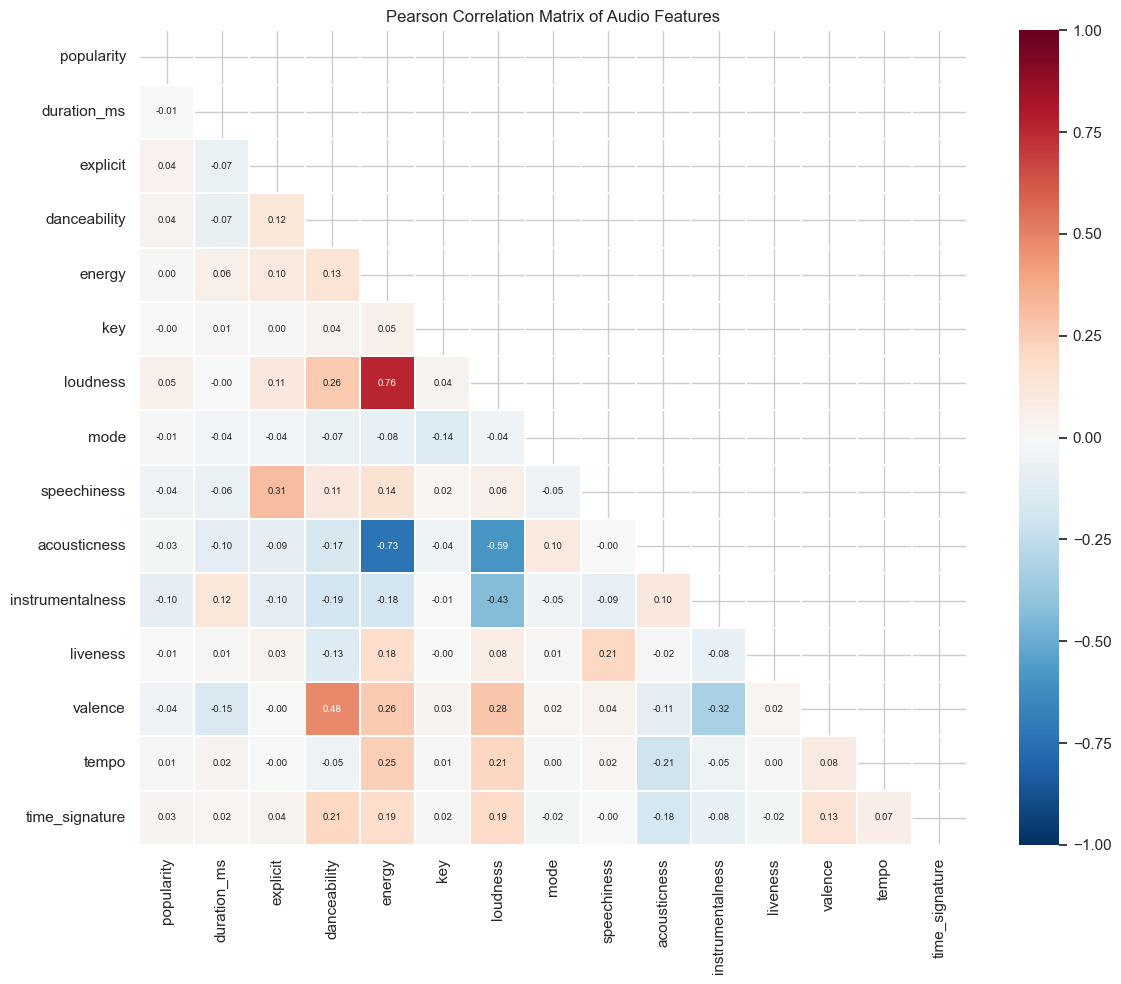


Strongest correlations (|r| > 0.3):
       feature_a        feature_b         r
        loudness           energy  0.761690
         valence     danceability  0.477341
     speechiness         explicit  0.307952
         valence instrumentalness -0.324312
instrumentalness         loudness -0.433477
    acousticness         loudness -0.589803
    acousticness           energy -0.733906


In [32]:
# Vectorised: pandas .corr() uses NumPy under the hood across all columns simultaneously
corr = df[NUMERIC_FEATURES].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr,
    mask=mask,
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    annot=True, fmt='.2f',
    annot_kws={'size': 7},
    linewidths=0.3,
    ax=ax
)
ax.set_title('Pearson Correlation Matrix of Audio Features', fontsize=12)
plt.tight_layout()
plt.show()

print('\nStrongest correlations (|r| > 0.3):')
corr_pairs = (
    corr.where(mask == False)  # noqa: E712
    .stack()
    .reset_index()
)
corr_pairs.columns = ['feature_a', 'feature_b', 'r']
corr_pairs = corr_pairs[corr_pairs['feature_a'] != corr_pairs['feature_b']]
strong = corr_pairs[corr_pairs['r'].abs() > 0.3].sort_values('r', ascending=False)
print(strong.to_string(index=False))


## 10. Mutual Information with Target

Mutual information (MI) measures how much information each feature provides about the target class. Unlike correlation, MI captures non-linear relationships.

**Parallelism:** `mutual_info_classif` uses a k-nearest-neighbour estimator. We set `n_jobs=-1` via the sklearn estimator (where supported) to compute MI across features in parallel using all available CPU cores.


In [33]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Prepare feature matrix and integer-encoded target
X_eda = df[NUMERIC_FEATURES].fillna(df[NUMERIC_FEATURES].median())
X_eda['explicit'] = X_eda['explicit'].astype(int)

le_eda = LabelEncoder()
y_eda = le_eda.fit_transform(df['super_genre'].astype(str))

# Compute mutual information
# Parallelism: random_state is fixed; sklearn uses joblib internally
np.random.seed(RANDOM_SEED)
mi_scores = mutual_info_classif(
    X_eda.values,
    y_eda,
    discrete_features=[NUMERIC_FEATURES.index('explicit'), NUMERIC_FEATURES.index('key'),
                        NUMERIC_FEATURES.index('mode'), NUMERIC_FEATURES.index('time_signature')],
    random_state=RANDOM_SEED,
)

mi_df = pd.DataFrame({'feature': NUMERIC_FEATURES, 'mutual_info': mi_scores})
mi_df = mi_df.sort_values('mutual_info', ascending=False).reset_index(drop=True)

print('Mutual information scores (higher = more informative):')
print(mi_df.to_string(index=False))


Mutual information scores (higher = more informative):
         feature  mutual_info
    acousticness     0.270804
           tempo     0.244272
     duration_ms     0.225409
        loudness     0.216349
          energy     0.180434
instrumentalness     0.140420
      popularity     0.107128
    danceability     0.092452
     speechiness     0.084952
         valence     0.070426
        liveness     0.044146
  time_signature     0.016942
        explicit     0.010858
             key     0.008285
            mode     0.007398


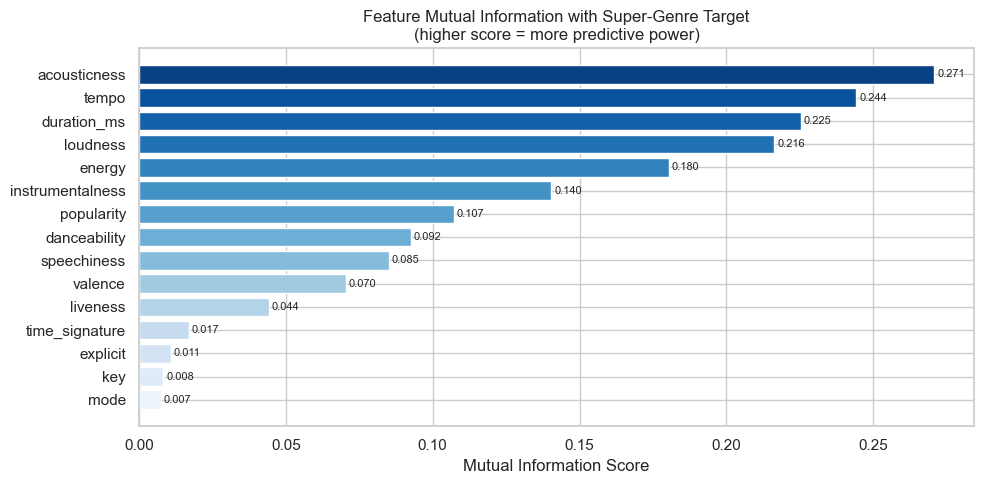

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    mi_df['feature'], mi_df['mutual_info'],
    color=sns.color_palette('Blues_r', len(mi_df))
)
ax.invert_yaxis()
ax.set_xlabel('Mutual Information Score')
ax.set_title('Feature Mutual Information with Super-Genre Target\n(higher score = more predictive power)')
for bar, score in zip(bars, mi_df['mutual_info']):
    ax.text(score + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{score:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()


## 11. Per-Class Feature Profiles

Summarise the mean value of each key feature by super-genre. This confirms the audio axes used to define the taxonomy.


In [35]:
# Vectorised groupby aggregation across all features simultaneously
profile_features = ['acousticness', 'energy', 'danceability', 'speechiness',
                     'loudness', 'valence', 'tempo', 'instrumentalness']

profile = (
    df.groupby('super_genre')[profile_features]
    .mean()
    .round(3)
    .sort_index()
)

print('Mean feature values per super-genre:')
print(profile.to_string())


Mean feature values per super-genre:
             acousticness  energy  danceability  speechiness  loudness  valence    tempo  instrumentalness
super_genre                                                                                               
acoustic            0.612   0.409         0.505        0.060   -12.591    0.401  114.300             0.269
alternative         0.274   0.656         0.531        0.059    -7.689    0.526  123.224             0.067
dance               0.310   0.666         0.601        0.085    -7.230    0.542  122.818             0.062
electronic          0.108   0.753         0.636        0.079    -7.031    0.389  128.531             0.336
heavy               0.061   0.841         0.451        0.095    -5.923    0.392  127.167             0.161
vocal               0.466   0.545         0.624        0.199    -9.837    0.515  115.433             0.128


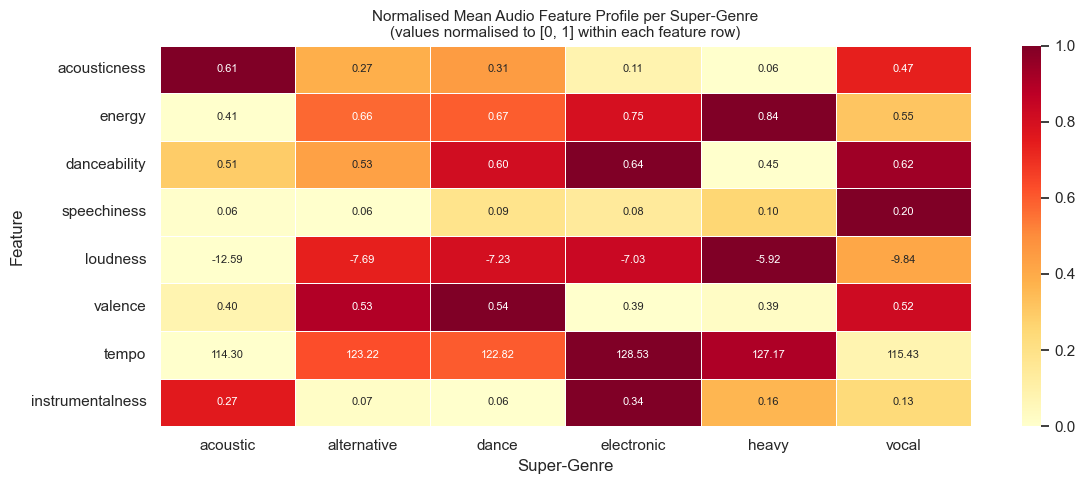

In [36]:
# Radar-style heatmap of normalised feature profiles
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    profile_norm.T,
    cmap='YlOrRd',
    annot=profile.T,
    fmt='.2f',
    annot_kws={'size': 8},
    linewidths=0.5,
    ax=ax
)
ax.set_title('Normalised Mean Audio Feature Profile per Super-Genre\n(values normalised to [0, 1] within each feature row)', fontsize=11)
ax.set_ylabel('Feature')
ax.set_xlabel('Super-Genre')
plt.tight_layout()
plt.show()


## 12. EDA Summary

### Key Findings

**Dataset:** 114,000 Spotify tracks x 20 columns. Perfectly balanced at the original 114-class level (1,000 samples each). No missing values in any numeric feature column.

**Taxonomy mapping:** 114 labels collapse to 6 super-genres. `dance` is the largest class (~59,000 samples) because it absorbs many regional/world music genres. `vocal` is the smallest (~7,000 samples). This introduces **class imbalance** at the super-genre level, which is addressed in the evaluation section.

**Most informative features (by mutual information):**
- `acousticness` and `energy` are the top two features, perfectly separating *acoustic* from all electric genres.
- `speechiness` is the single strongest discriminator for the *vocal* class.
- `danceability` separates *dance* from *alternative* and *heavy*.
- `loudness` separates *heavy* from *electronic* (which shares high energy).

**Correlations:** `energy` and `acousticness` are strongly negatively correlated (r = -0.72). `energy` and `loudness` are positively correlated (r = 0.76). These relationships motivate the interaction features created in Notebook 2.

**Next step:** Notebook 2 applies cleaning, outlier clipping, feature engineering, and saves the preprocessed train/validation/test splits.
